# pK Distribution

This notebook will look at the distribution of pK values in the test and training sets for the CASF-2016 and OOD Test benchmarks. (Note it may not be possible for this notebook to run without first preprocessing some of the data as outlined in the README).

In [26]:
# Get project root for file paths
from pathlib import Path

notebook_path = Path().resolve()
project_root = notebook_path.parent
data_dir = project_root / "data"
plots_dir = project_root / "output" / "notebook_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [27]:
import pandas as pd

# Get paths to the train, val, test processed csvs. 
# Instructions on how to generate these are in the readme

casf_2016_train = data_dir / "PDBbind_processed_train.csv"
casf_2016_val = data_dir / "PDBbind_processed_val.csv"
casf_2016_test = data_dir / "CASF_2016_processed.csv"

ood_test_train = data_dir / "OOD_Test_processed_train.csv"
ood_test_val = data_dir / "OOD_Test_processed_val.csv"
ood_test_test = data_dir / "OOD_Test_processed_test.csv"



In [35]:
df_casf_2016_train = pd.read_csv(casf_2016_train)
df_casf_2016_val = pd.read_csv(casf_2016_val)
df_casf_2016_test = pd.read_csv(casf_2016_test)

df_ood_test_train = pd.read_csv(ood_test_train)
df_ood_test_val = pd.read_csv(ood_test_val)
df_ood_test_test = pd.read_csv(ood_test_test)

# Concatenate the train and val for the histogram
df_casf_2016_full_train = pd.concat([df_casf_2016_train, df_casf_2016_val], axis=0, ignore_index=True)
df_ood_test_full_train = pd.concat([df_ood_test_train, df_ood_test_val], axis=0, ignore_index=True)

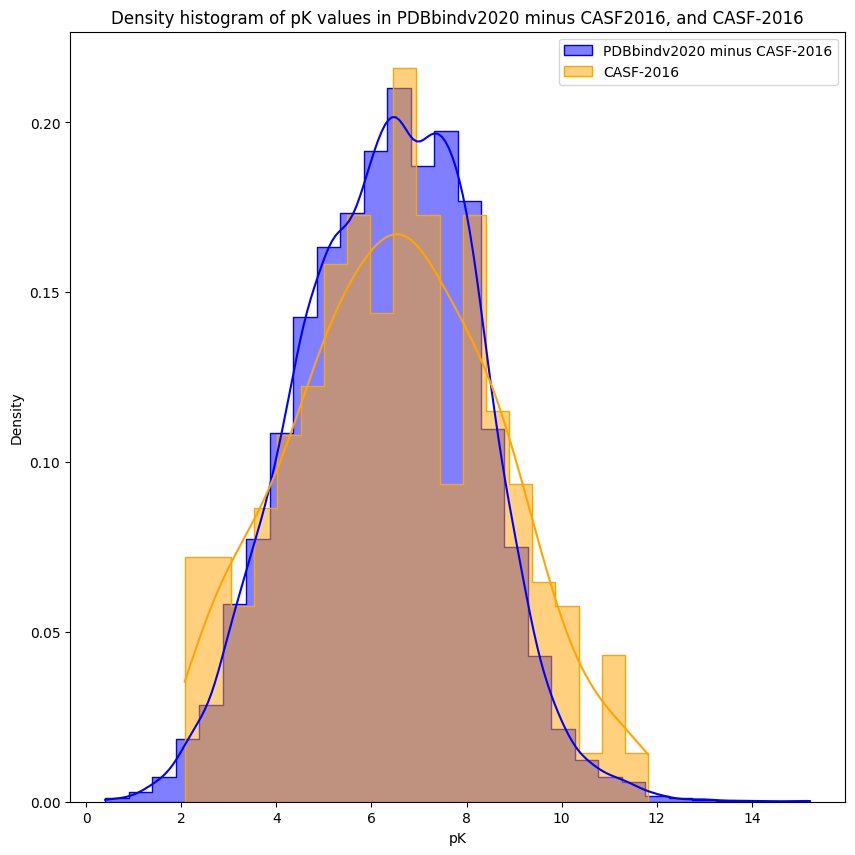

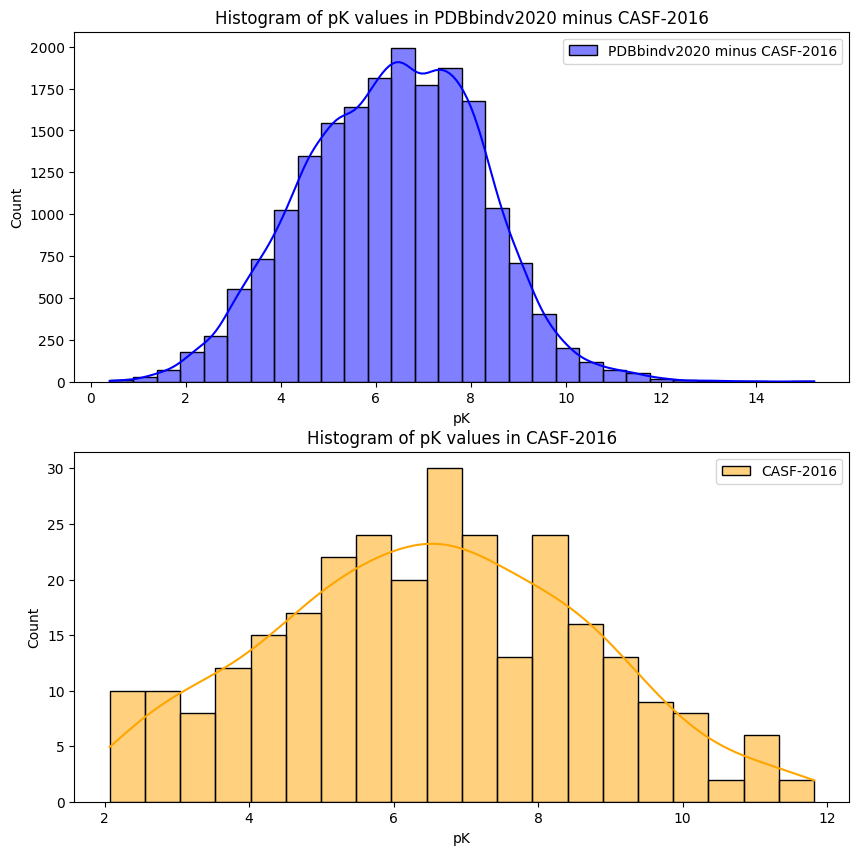

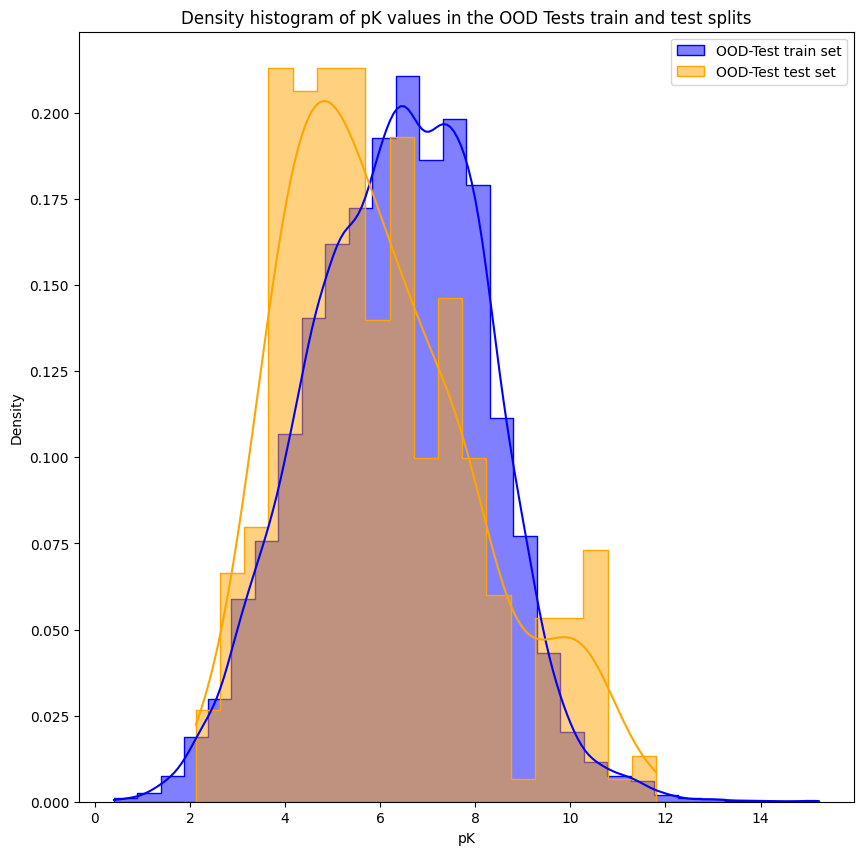

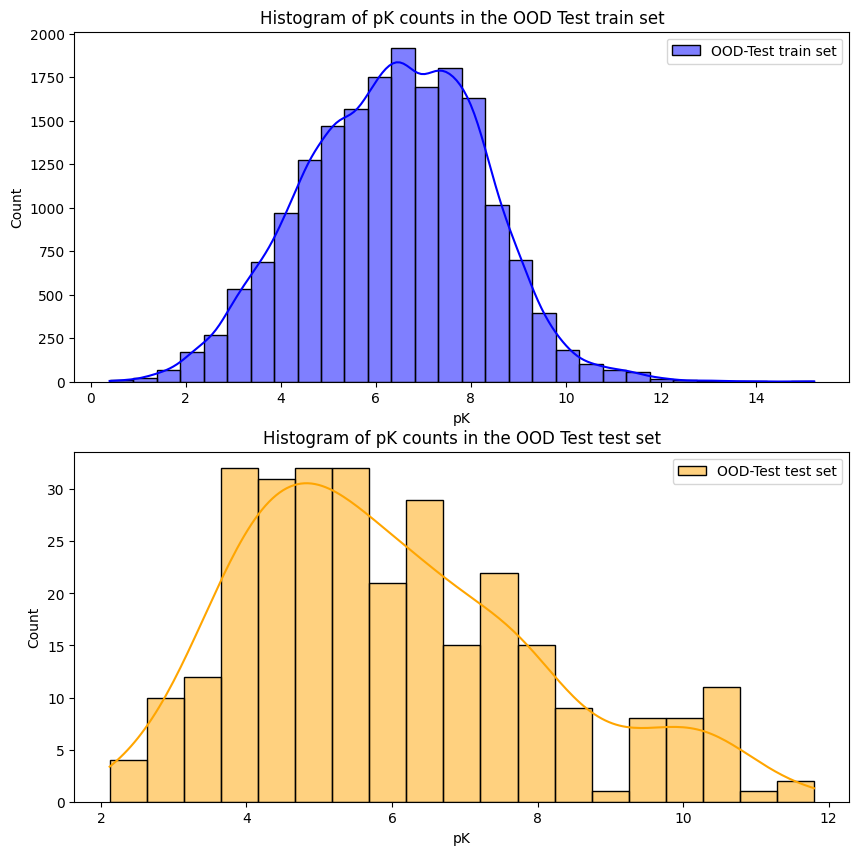

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the histograms

# Joint density histogram
fig = plt.figure(figsize=(10,10))
sns.histplot(
    data=df_casf_2016_full_train, 
    x="pK", 
    color="blue", 
    label="PDBbindv2020 minus CASF-2016", 
    element="step", 
    binwidth=0.5,
    stat="density", # normalise so that total area of histogram equals 1
    common_norm=False, # normalise each histogram separately
    kde=True
)

sns.histplot(
    data=df_casf_2016_test, 
    x="pK", 
    color="orange", 
    label="CASF-2016", 
    element="step", 
    binwidth=0.5,
    stat="density", # normalise so that total area of histogram equals 1
    common_norm=False, # normalise each histogram separately
    kde=True
)
plt.legend()
plt.xlabel("pK")
plt.title("Density histogram of pK values in PDBbindv2020 minus CASF2016, and CASF-2016")

img_path = plots_dir / "density_hist_pk_PDBbind_CASF_2016.png"
fig.savefig(fname=img_path)
plt.show()

# Separate histograms of raw counts:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10)) # 2 rows 1 col

sns.histplot(
    data=df_casf_2016_full_train,
    x="pK",
    color="blue",
    label="PDBbindv2020 minus CASF-2016",  
    binwidth=0.5,
    kde=True,
    ax=ax1
)
ax1.legend()
ax1.set_title("Histogram of pK values in PDBbindv2020 minus CASF-2016")

sns.histplot(
    data=df_casf_2016_test, 
    x="pK", 
    color="orange", 
    label="CASF-2016", 
    binwidth=0.5,
    kde=True,
    ax=ax2
)
ax2.legend()
ax2.set_title("Histogram of pK values in CASF-2016")

img_path = plots_dir / "count_hist_pk_PDBbind_CASF_2016.png"
fig.savefig(fname=img_path)
plt.show()

# Same for OOD Test
fig = plt.figure(figsize=(10,10))
sns.histplot(
    data=df_ood_test_full_train, 
    x="pK", 
    color="blue", 
    label="OOD-Test train set", 
    element="step", 
    binwidth=0.5,
    stat="density", # normalise so that total area of histogram equals 1
    common_norm=False, # normalise each histogram separately
    kde=True
)

sns.histplot(
    data=df_ood_test_test, 
    x="pK", 
    color="orange", 
    label="OOD-Test test set", 
    element="step", 
    binwidth=0.5,
    stat="density", # normalise so that total area of histogram equals 1
    common_norm=False, # normalise each histogram separately
    kde=True
)
plt.legend()
plt.xlabel("pK")
plt.title("Density histogram of pK values in the OOD Tests train and test splits")
img_path = plots_dir / "density_hist_pk_OOD_Test.png"
fig.savefig(img_path)
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10)) # 2 rows 1 col

sns.histplot(
    data=df_ood_test_full_train, 
    x="pK", 
    color="blue", 
    label="OOD-Test train set", 
    binwidth=0.5,
    kde=True,
    ax=ax1
)
ax1.legend()
ax1.set_title("Histogram of pK counts in the OOD Test train set")

sns.histplot(
    data=df_ood_test_test, 
    x="pK", 
    color="orange", 
    label="OOD-Test test set", 
    binwidth=0.5,
    kde=True,
    ax=ax2
)
ax2.legend()
ax2.set_title("Histogram of pK counts in the OOD Test test set")
img_path = plots_dir / "count_hist_pk_OOD_Test.png"
fig.savefig(img_path)

plt.show()